In [ ]:
Code : To convert to different Color Models

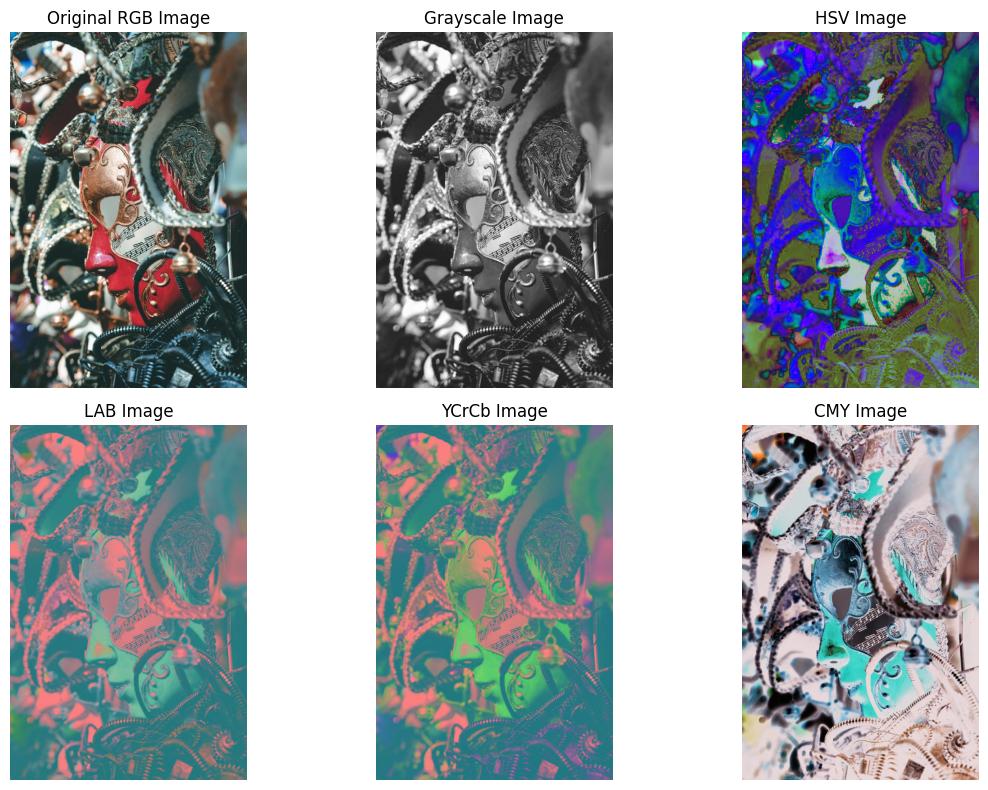

In [8]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\JAI\Downloads\mask.jpeg")

def convert_to_cmy(img):
    rgb_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_normalized = rgb_image / 255.0
    cmy_image = 1 - rgb_normalized
    return cmy_image

def plot_image(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    ycrcb_image = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    cmy_image = convert_to_cmy(image)
    
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(rgb_image)
    plt.title("Original RGB Image")
    plt.axis("off")
    plt.subplot(2, 3, 2)
    plt.imshow(gray_image, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.subplot(2, 3, 3)
    plt.imshow(hsv_image)
    plt.title("HSV Image")
    plt.axis("off")
    plt.subplot(2, 3, 4)
    plt.imshow(lab_image)
    plt.title("LAB Image")
    plt.axis("off")
    plt.subplot(2, 3, 5)
    plt.imshow(ycrcb_image)
    plt.title("YCrCb Image")
    plt.axis("off")
    plt.subplot(2, 3, 6)
    plt.imshow(cmy_image)
    plt.title("CMY Image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

if img is None:
    print("Error: Image not found.")
    exit()

plot_image(img)


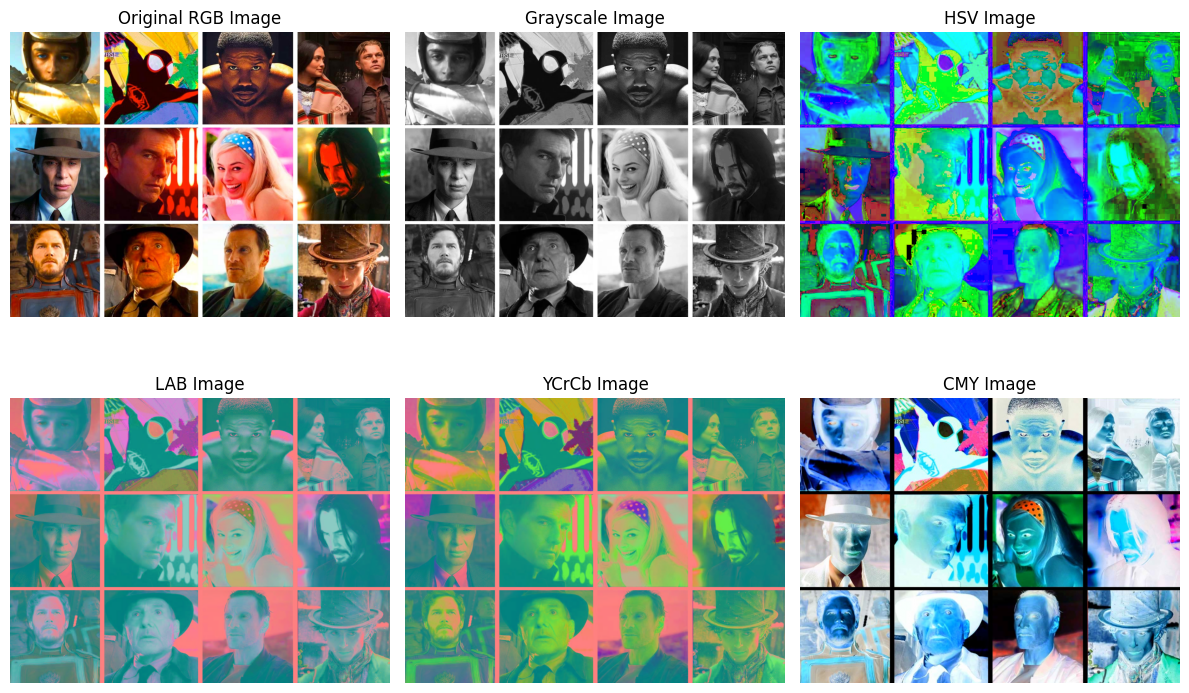

In [11]:
img = cv2.imread(r"C:\Users\JAI\Downloads\movie.jpg")
if img is None:
    print("Error")
else:
    plot_image(img)

In [ ]:
Code : To make empty matrix to give some color based on random value 

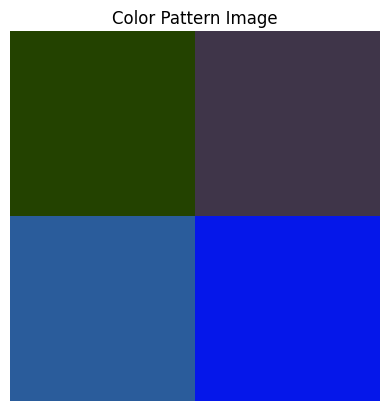

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def create_color_pattern_image(height, width):
   
    image = np.zeros((height, width, 3), dtype=np.uint8)
    

    image[:height//2, :width//2] = [35,66,0.234] 
    

    image[:height//2, width//2:] = [63,53, 73]  
    

    image[height//2:, :width//2] = [42, 92, 155]  
    
 
    image[height//2:, width//2:] = [5, 23, 234]  
    
    return image


color_image = create_color_pattern_image(100,100)

plt.imshow(color_image)
plt.title("Color Pattern Image")
plt.axis("off")  # Turn off axis
plt.show()


In [ ]:
Code : TO split the image Red,Blue and Green separately

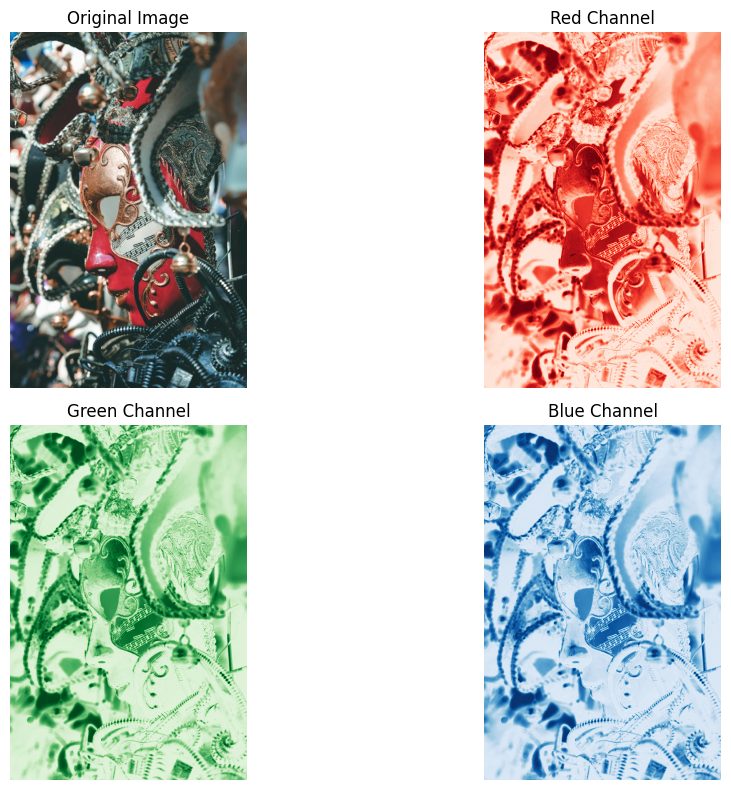

In [14]:
from PIL import Image
import matplotlib.pyplot as plt

def display_rgb_channels(image_path):


    img = Image.open(image_path)

    r, g, b = img.split()

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")
    
    plt.subplot(2, 2, 2)
    plt.title("Red Channel")
    plt.imshow(r, cmap="Reds")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.title("Green Channel")
    plt.imshow(g, cmap="Greens")
    plt.axis("off")

    plt.subplot(2, 2, 4)
    plt.title("Blue Channel")
    plt.imshow(b, cmap="Blues")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

image_path = r"C:\Users\JAI\Downloads\mask.jpeg"
display_rgb_channels(image_path)


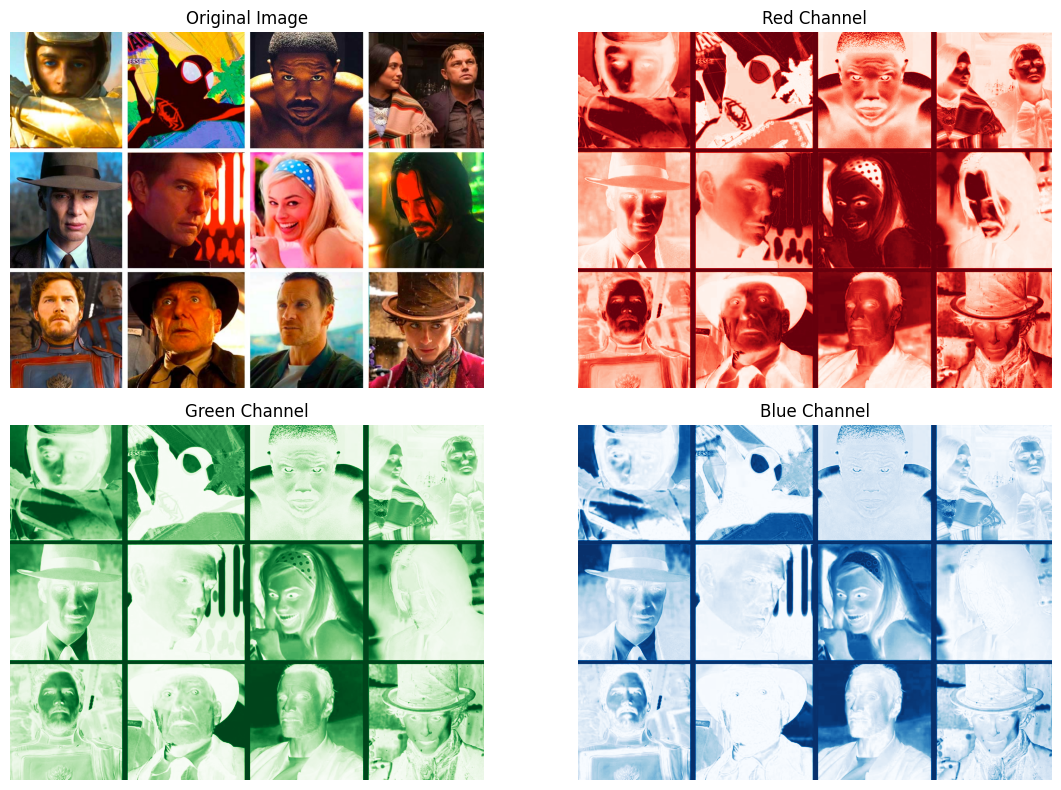

In [15]:
img  = r"C:\Users\JAI\Downloads\movie.jpg"
display_rgb_channels(img)

In [ ]:
Code : TO split the image Hue,Saturation and Value separately

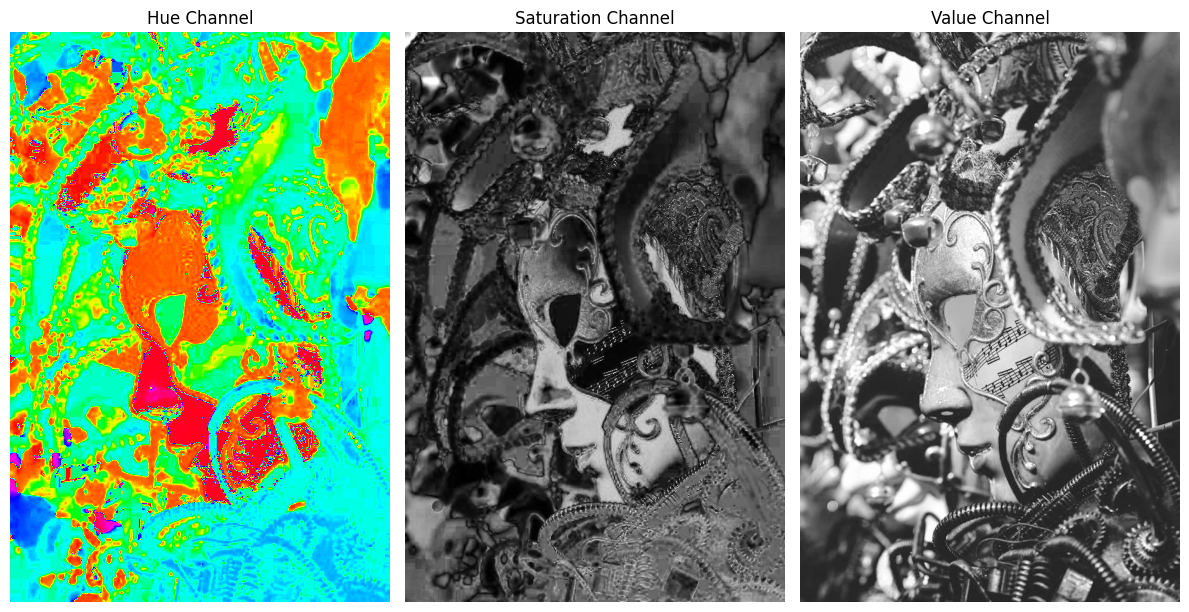

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def separate_hsv_planes(image):
    
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    hue, saturation, value = cv2.split(hsv_image)
    
    return hue, saturation, value

def display_hsv_planes(image):

    hue, saturation, value = separate_hsv_planes(image)
    
  
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(hue, cmap="hsv")
    plt.title("Hue Channel")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(saturation, cmap="gray")
    plt.title("Saturation Channel")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(value, cmap="gray")
    plt.title("Value Channel")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()


image_path = r"C:\Users\JAI\Downloads\mask.jpeg"
image = cv2.imread(image_path)  


if image is None:
    print(f"Error: Unable to load the image at {image_path}. Check the path and file.")
    exit()


display_hsv_planes(image)


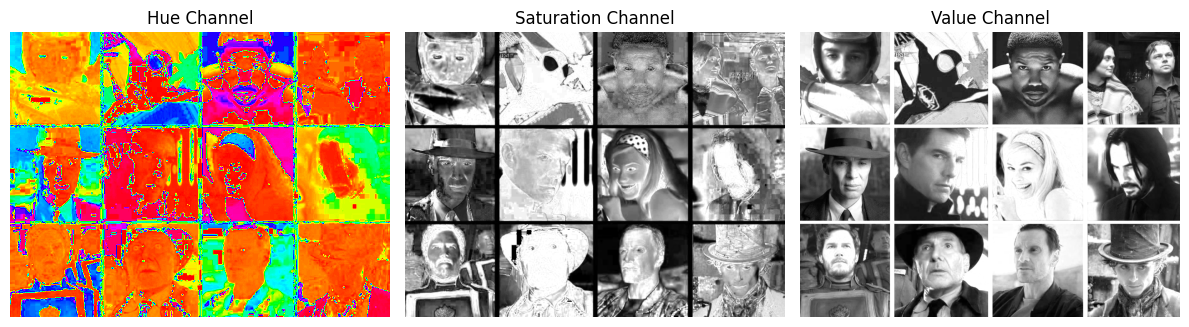

In [17]:
image_path = r"C:\Users\JAI\Downloads\movie.jpg"
image = cv2.imread(image_path) 
display_hsv_planes(image)

In [ ]:
Code : TO split the image andjust and seperate Hue,Saturation and Valueuniquely

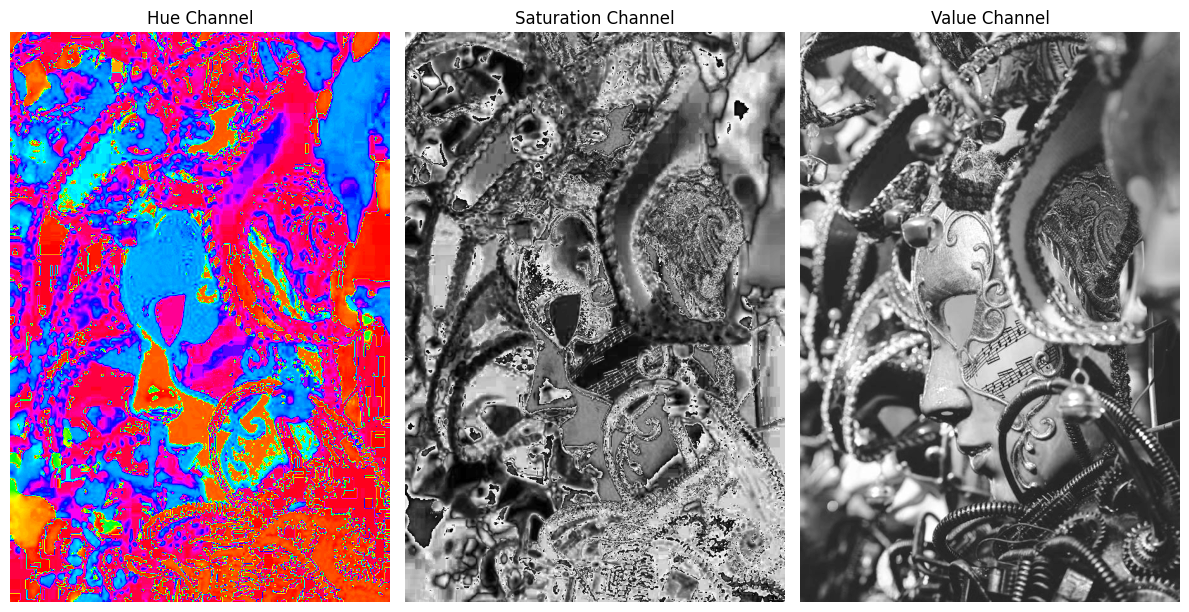

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def adjust_hsv(image, hue_shift=0, saturation_scale=1.0, value_scale=1.0):

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    hue, saturation, value = cv2.split(hsv_image)
    
    hue = (hue + hue_shift) % 180
    
    saturation = np.clip(saturation * saturation_scale, 0, 255).astype(np.uint8)
    
    value = np.clip(value * value_scale, 0, 255).astype(np.uint8)
    
    adjusted_hsv = cv2.merge((hue, saturation, value))
    return adjusted_hsv

def display_hsv_planes(hsv_image):
 
    hue, saturation, value = cv2.split(hsv_image)
    
    plt.figure(figsize=(12, 8))
    
    plt.subplot(1, 3, 1)
    plt.imshow(hue, cmap="hsv")  
    plt.title("Hue Channel")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(saturation, cmap="gray") 
    plt.title("Saturation Channel")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(value, cmap="gray")  
    plt.title("Value Channel")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

image_path = r"C:\Users\JAI\Downloads\mask.jpeg"
image = cv2.imread(image_path) 


if image is None:
    print(f"Error: Unable to load the image at {image_path}. Check the path and file.")
    exit()

hue_shift = 90         
saturation_scale = 2  
value_scale = 1      

adjusted_hsv = adjust_hsv(image, hue_shift, saturation_scale, value_scale)

display_hsv_planes(adjusted_hsv)


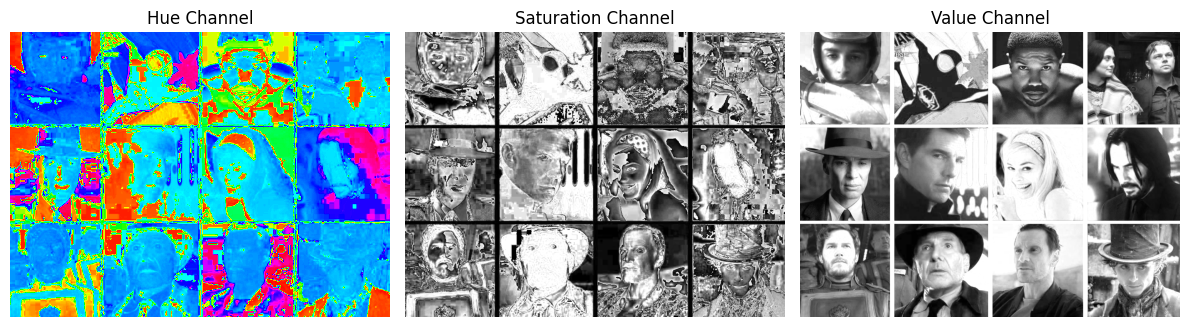

In [2]:
image_path = r"C:\Users\JAI\Downloads\movie.jpg"
image = cv2.imread(image_path) 
hue_shift = 90         
saturation_scale = 2  
value_scale = 1  
adjusted_hsv = adjust_hsv(image, hue_shift, saturation_scale, value_scale)

display_hsv_planes(adjusted_hsv)

In [ ]:
Code : TO split the image andjust and seperate Hue,Saturation and Value uniquely then combined it with RGB and BGR

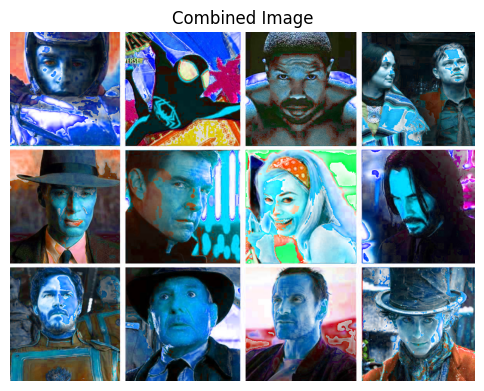

In [3]:
def display_combined_image(hsv_image):
  
    bgr_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)  
    
    plt.figure(figsize=(6, 6))
    plt.imshow(rgb_image)
    plt.title("Combined Image")
    plt.axis("off")
    plt.show()
display_combined_image(adjusted_hsv)
